# Poisson equation in 1D

Diferential equation:
$$\frac{d^2y}{dx^2}+\pi^2\sin(\pi x)=0,\qquad x\in[-1,1]$$

Boundary Conditions:
$$ y(-1)=0,\qquad y(1)=0$$

Analytical Solution
$$ y(x)= \sin(\pi x)$$


Hiperparámetros:
- dde.geometry.Interval


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import deepxde as dde
from deepxde.backend import tf

2025-05-21 14:32:45.366146: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-21 14:32:45.605362: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-21 14:32:45.821578: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747859566.010228    4264 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747859566.061772    4264 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747859566.460163    4264 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [4]:
print("Backend en uso:", dde.backend.backend_name)

Backend en uso: tensorflow


## Primer paso.
## Definir la ecuacion diferencial

- $x$ es la variable independiente y $y$ la dependiente.
- dde.grad.hessian(y,x): calcula la segunda derivada de $y$ respecto a $x$.

In [3]:
def pde(x,y):
    dy_xx = dde.grad.hessian(y,x)
    return dy_xx + np.pi**2 * tf.sin(np.pi * x)

## Segundo paso
## Definir el rango y la frontera

In [6]:
# Se crea un objeto con geometria 1D
# rango de la variable independiente x
geom = dde.geometry.Interval(-1,1)

In [12]:
x_train = np.linspace(-1,1,100).reshape(-1,1)
x_train = tf.convert_to_tensor(x_train, dtype=tf.float32)

In [13]:
x_train

<tf.Tensor: shape=(100, 1), dtype=float32, numpy=
array([[-1.        ],
       [-0.97979796],
       [-0.959596  ],
       [-0.93939394],
       [-0.9191919 ],
       [-0.8989899 ],
       [-0.8787879 ],
       [-0.85858583],
       [-0.83838385],
       [-0.8181818 ],
       [-0.7979798 ],
       [-0.7777778 ],
       [-0.75757575],
       [-0.7373737 ],
       [-0.7171717 ],
       [-0.6969697 ],
       [-0.67676765],
       [-0.65656567],
       [-0.6363636 ],
       [-0.61616164],
       [-0.5959596 ],
       [-0.57575756],
       [-0.5555556 ],
       [-0.53535354],
       [-0.5151515 ],
       [-0.4949495 ],
       [-0.47474748],
       [-0.45454547],
       [-0.43434343],
       [-0.41414142],
       [-0.3939394 ],
       [-0.37373737],
       [-0.35353535],
       [-0.33333334],
       [-0.3131313 ],
       [-0.2929293 ],
       [-0.27272728],
       [-0.25252524],
       [-0.23232323],
       [-0.21212122],
       [-0.1919192 ],
       [-0.17171717],
       [-0.15151516],
    

In [5]:
def boundary(x, on_boundary):
    return on_boundary
# on_boundary is a boolean value, that indicates if the point x lies on the boundary or not.
# It's needed because somethimes no all the boundaries are aplied 

def boundary_func(x):
    return 0

In [17]:
def exact_sol(x):
    return np.sin(np.pi * x)

Esta línea crea un objeto que define las configuraciones del problema antes de entrenarlo

<code>
data = dde.data.PDE(geom, pde, bc, 16, 2, solution=exact_sol, num_test=100)
</code>

- 16: es el numero de puntos que se entrenan muestrados del dominio
- 2:  Es el numero de puntos en la frontera


In [18]:
bc = dde.icbc.DirichletBC(geom, boundary_func, boundary)
data = dde.data.PDE(geom, pde, bc, 16, 2, solution=exact_sol, num_test=100)



1. layer_size: Define la arquitectura de la red neuronal. El numero de neuronas en cada capa
<code>
layer_size = [1] + [50] * 3 + [1] = [1,50,50,50,1]
</code>

    - 1: Porque es 1D
    - 50:  50 neuronas en 3 capas escondidas.
    - 1: Porque la salida es tambien una y(x)
    
<br>
<br>
2. activation = tanh <br>
.<br>

    - tanh es hyperbolic tangent. Esta es unsada comunmente en RN porque introduce no linealidad y tiene un gradiente suave. Esto ayuda a la convergencia
    
    
3. initializer = "Glorot uniform" <br>
.<br>

    - Esto especifica el peso y los biases de inicialización. Este es usado comunmente para inicializar pesos de una red que sea estable el entrenamiento, evitando que se anule o exploten gradientes.
- 



In [20]:
layer_size = [1] + [50] * 3 + [1]
activation = "tanh"
initializer = "Glorot uniform"

net = dde.nn.FNN(layer_size,activation,initializer)

In [21]:
model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])

losshistory, train_state = model.train(iterations=1000)

Compiling model...
'compile' took 0.031519 s

Training model...

Step      Train loss              Test loss               Test metric   
0         [4.34e+01, 9.11e-04]    [4.91e+01, 9.11e-04]    [1.02e+00]    
1000      [5.19e-04, 5.03e-07]    [6.11e-04, 5.03e-07]    [6.97e-04]    

Best model at step 1000:
  train loss: 5.19e-04
  test loss: 6.11e-04
  test metric: [6.97e-04]

'train' took 4.072575 s



## Visualizacion de resultados 


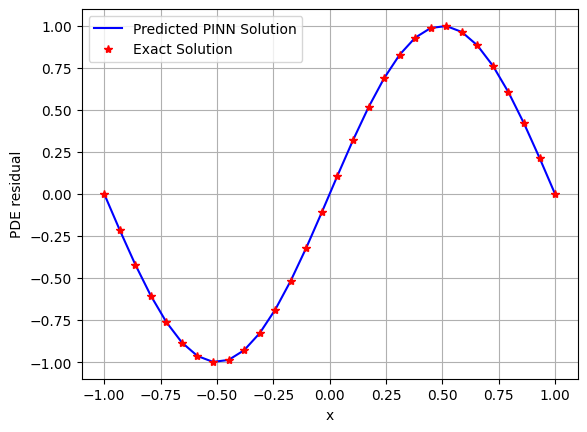

In [25]:
x = geom.uniform_points(30, True)
y_pred = model.predict(x)

y_exact = exact_sol(x)

plt.figure()
plt.plot(x, y_pred, color ='b', label="Predicted PINN Solution")
plt.plot(x, y_exact, "*", color="r", label= "Exact Solution")

plt.xlabel("x")
plt.ylabel("PDE residual")

plt.legend(loc="best")
plt.grid()
plt.show()

In [ ]:


x_bc = np.array([[-1.0],[1.0]],dtype=np.float32)

In [ ]:
]